# Titanic Data Analysis
**Tool:** Numpy Pandas Mateplotlib Seaborn  
**Data set:** Titanic Data set  
**Goal:** Data manipulation & visulaization  

---


##  Step 1: Import Libraries
We import all necessary libraries for data manipulation and visualization.

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Step 2: Load Dataset
We load the Titanic CSV file into a Pandas DataFrame and take a first look at the data.

In [90]:
df=pd.read_csv('titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3 : Inspect data
**Cheak:** shape , info , describe  

In [91]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Step : 4 Data qulaity cheak

In [92]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [93]:
df.duplicated().sum()


np.int64(0)

In [94]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

# Step : 5 Data Cleaning 
**Missing:** Age Cabin and Embark has missing values  
cabin has 77% missing values we drop cabin coulumn
 

In [95]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df.drop('Cabin',axis=1,inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17208\3832809384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_17208\3832809384.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [96]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Step : 6 Drop unnecessary columns
**Columns:** Passenge id , Name , Ticket  

In [97]:
df.drop(['Ticket', 'PassengerId', 'Name'], axis=1, inplace=True)

In [98]:
# Cheak the data after cleaning or droping the columns
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Step : 6 Feature Engineering 
Family Size , IsAlone , AgeGroup  

In [99]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
df['IsAlone'].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [100]:
def age_group(age):
    if age <=12:
        return 'Child'
    elif age <= 25:
        return 'Young'
    elif age <=50:
        return 'Adult'
    else:
        return 'Senior'
    
df['AgeGroup']=df['Age'].apply(age_group)
df['AgeGroup'].value_counts()

AgeGroup
Adult     526
Young     232
Child      69
Senior     64
Name: count, dtype: int64

In [101]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,2,0,Young
1,1,1,female,38.0,1,0,71.2833,C,2,0,Adult
2,1,3,female,26.0,0,0,7.9250,S,1,1,Adult
3,1,1,female,35.0,1,0,53.1000,S,2,0,Adult
4,0,3,male,35.0,0,0,8.0500,S,1,1,Adult


In [111]:
# Saved the cleaned data to a new CSV file
df.to_csv('titanic_cleaned.csv', index=False)
print("Data cleaning complete. Cleaned data saved to 'titanic_cleaned.csv'.")

Data cleaning complete. Cleaned data saved to 'titanic_cleaned.csv'.


# Step : 7 EDA & Visualization 

C:\Users\Dell\AppData\Local\Temp\ipykernel_17208\763653834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df,palette='Set1')


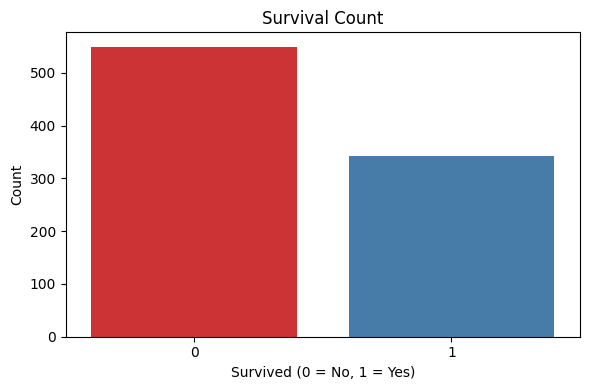

In [102]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df,palette='Set1')
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Visualization 1 — Survival Count

**Key Finding:**
- **549 passengers** did not survive (0) — 61.6%
- **342 passengers** survived (1) — 38.4%
- Majority of Titanic passengers **did not survive**
- Only **38%** of people made it out alive

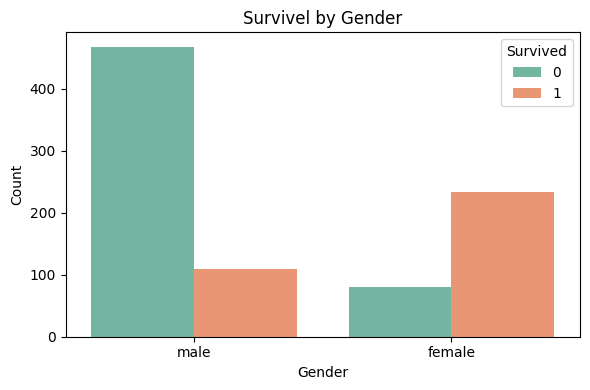

In [103]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived',data=df,palette='Set2')
plt.title('Survivel by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##  Visualization 2 — Survival by Gender

**Key Finding:**
- **Females survived much more** than males
- Female survival: ~235 out of ~314 = **74.8%**
- Male survival: ~109 out of ~577 = **18.9%**
- "Women and children first" policy clearly visible in data
- Gender was the **strongest survival factor** on Titanic

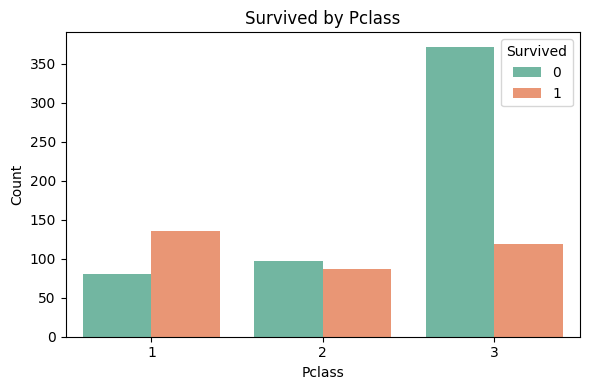

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass',hue='Survived',data=df,palette='Set2')
plt.title('Survived by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##  Visualization 3 — Survival by Passenger Class

** Key Finding:**
- **1st Class** passengers survived the most — ~63% survival rate
- **2nd Class** — ~47% survival rate
- **3rd Class** survived the least — only ~24% survival rate
- Clear pattern: **Richer passengers had better survival chances**
- 3rd Class had 372 deaths — highest among all classes
- Money literally bought survival on Titanic 

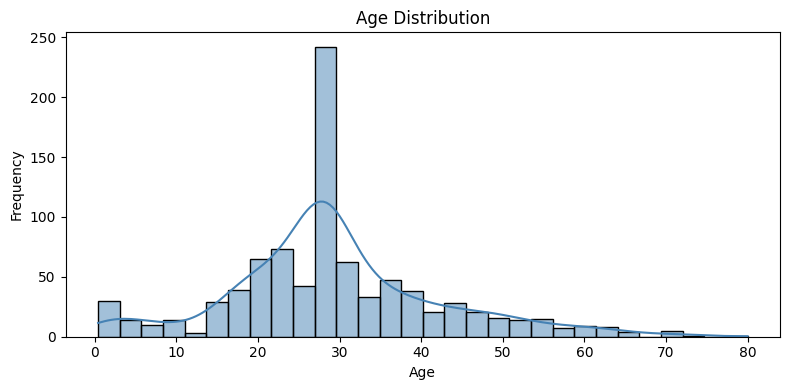

In [105]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'].dropna(),bins=30,kde=True,color='steelblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##  Visualization 4 — Age Distribution

** Key Finding:**
- Majority of passengers were **20-35 years old** (young adults)
- Peak age group around **28-30 years**
- Distribution is **right-skewed** — fewer older passengers (60+)
- Small bump at **0-5 years** — some children were on board
- Average age approximately **29-30 years**

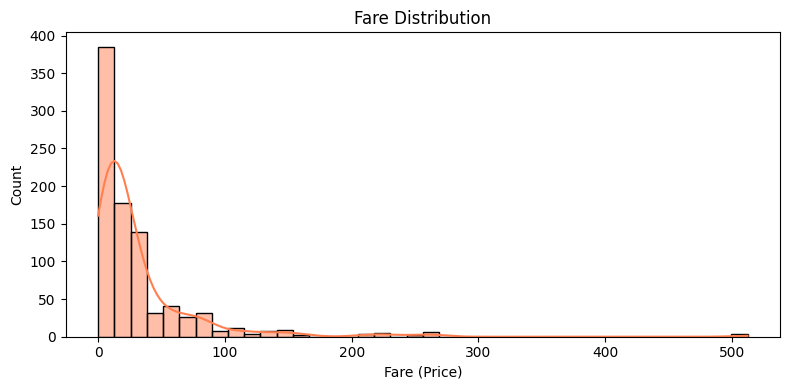

In [106]:
plt.figure(figsize=(8,4))
sns.histplot(df['Fare'], bins=40, kde=True, color='coral')
plt.title('Fare Distribution')
plt.xlabel('Fare (Price)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Visualization 5 — Fare Distribution

** Key Finding:**
- Distribution is **heavily right-skewed**
- Majority of passengers paid **very low fare ($0-50)** — 3rd Class
- Very few passengers paid **extremely high fare ($300-500)** — 1st Class VIPs
- Huge gap between rich and poor passengers
- Outliers at $500+ indicate **ultra-rich first class** passengers

C:\Users\Dell\AppData\Local\Temp\ipykernel_17208\2041837014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, palette='coolwarm')


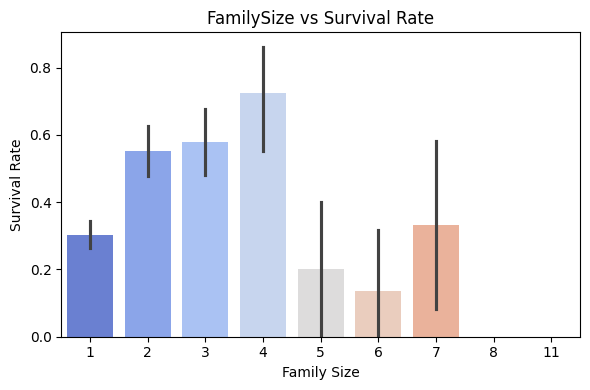

In [107]:
plt.figure(figsize=(6,4))
sns.barplot(x='FamilySize', y='Survived', data=df, palette='coolwarm')
plt.title('FamilySize vs Survival Rate')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

##  Visualization 6 — FamilySize vs Survival Rate

**Key Finding:**
- **Akele passengers (FamilySize=1)** ka survival rate sirf ~30% — lowest
- **Small families (2-4)** ka survival rate sabse zyada ~55-72%
- **Badi families (5+)** ka survival rate bohot kam ~15-20%
- Sweet spot: **2-4 family members** saath hone se survival chances best the
- Very large families struggled to evacuate together
- "Together but not too many" = best survival strategy 🚢

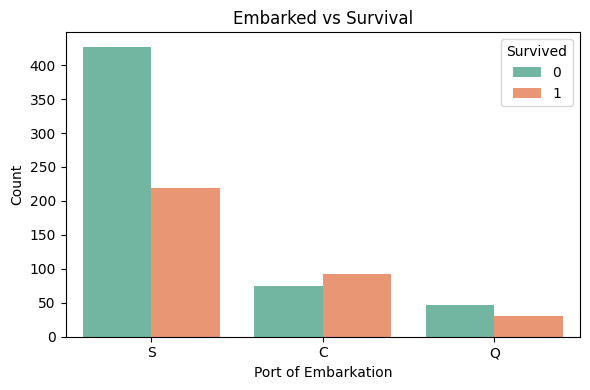

In [108]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set2')
plt.title('Embarked vs Survival')
plt.xlabel('Port of Embarkation')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Visualization 7 — Embarked vs Survival

**Key Finding:**
- **Cherbourg (C)** passengers had best survival rate — more 1st Class passengers boarded here
- **Southampton (S)** had the most passengers but poor survival rate — mostly 3rd Class
- **Queenstown (Q)** had the least passengers and lowest survival count
- Port of embarkation indirectly reflects **passenger class and wealth**

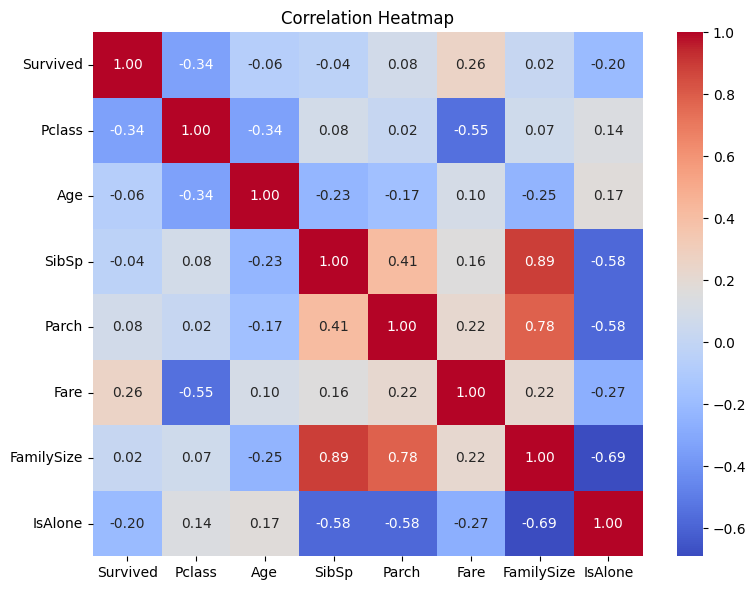

In [109]:
plt.figure(figsize=(8,6))
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##  Visualization 8 — Correlation Heatmap

** Key Findings:**
- **Fare vs Survived (+0.26)** — Zyada fare dene waale zyada survive kiye (1st Class)
- **Pclass vs Survived (-0.34)** — Higher class number = kam survival (3rd Class worst)
- **Pclass vs Fare (-0.55)** — 1st Class ne zyada fare diya, obvious!
- **SibSp vs FamilySize (+0.89)** — Strong relation, FamilySize SibSp se hi bana hai
- **IsAlone vs FamilySize (-0.69)** — Akele log = chhoti family, expected
- **Age vs Pclass (-0.34)** — Older passengers were more likely in higher classes

In [110]:
# Final check
print("Dataset Shape:", df.shape)
print("\nFeatures:", df.columns.tolist())
print("\nSurvival Rate:", round(df['Survived'].mean()*100, 2), "%")

Dataset Shape: (891, 11)

Features: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']

Survival Rate: 38.38 %


##  Project Summary — Titanic Data Analysis

| Detail | Info |
|--------|------|
| **Dataset** | Titanic Passenger Data |
| **Total Records** | 891 rows |
| **Total Features** | 11 (8 original + 3 engineered) |
| **Overall Survival Rate** | 38.38% |
| **Tools Used** | Python, Pandas, NumPy, Matplotlib, Seaborn |

###  Key Insights:
1. Only **38.38%** passengers survived — majority did not make it
2. **Females** had 74.8% survival rate vs males only 18.9%
3. **1st Class** passengers survived the most (~63%) — wealth mattered
4. **Small families (2-4)** had the best survival chances
5. **Cherbourg (C)** port passengers survived more — mostly 1st Class
6. **Higher fare** = higher survival — strong positive correlation (+0.26)

###  Feature Engineering:
- `FamilySize` = SibSp + Parch + 1
- `IsAlone` = 1 if FamilySize == 1
- `AgeGroup` = Child / Young / Adult / Senior

###  Skills Demonstrated:
- Data Loading & Inspection
- Data Cleaning (null handling, column dropping)
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization (Matplotlib + Seaborn)
- Business Insight Extraction

---
**Author:** Waleed Ahmad | BS Data Science (2nd Semester)— Riphah International University
**GitHub:** [mianwaleed155847-hub](https://github.com/mianwaleed155847-hub)